### Setup and Data Loading

In [6]:
# Hiding warnings for a clean notebook

import warnings
warnings.filterwarnings('ignore')

from transformers.utils import logging as hf_logging
hf_logging.set_verbosity_error()

from datasets.utils import logging
logging.set_verbosity_error()

In [7]:
# Checking device

import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


In [9]:
# Loading datasets

from datasets import load_dataset

dataset = load_dataset("timm/eurosat-rgb")

# Checking the dataset
print(dataset)
print(dataset['train'].features['label'].names)

DatasetDict({
    train: Dataset({
        features: ['image', 'label', 'image_id'],
        num_rows: 16200
    })
    validation: Dataset({
        features: ['image', 'label', 'image_id'],
        num_rows: 5400
    })
    test: Dataset({
        features: ['image', 'label', 'image_id'],
        num_rows: 5400
    })
})
['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


### ViT Pipeline

In [10]:
# Preprocessing

import numpy as np
import evaluate
from transformers import ViTImageProcessor, ViTForImageClassification, TrainingArguments, Trainer

vit = "google/vit-base-patch16-224-in21k"
processor = ViTImageProcessor.from_pretrained(vit)

# Gets label mappings both ways
labels = dataset['train'].features['label'].names
label2id = {label: idx for idx, label in enumerate(labels)}
id2label = {idx: label for idx, label in enumerate(labels)}

print("Labels:", labels)
print("Processor:", processor)

# Preprocess function, takes the images from the batch and returns PyTorch tensor, and adds the label too.
def vit_preprocess(batch):
    inputs = processor(images=batch['image'], return_tensors='pt')
    inputs['labels'] = batch['label']
    return inputs

vit_processed = dataset.map(vit_preprocess, batched=True, remove_columns=['image', 'image_id'])
vit_processed.set_format('torch')

Labels: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
Processor: ViTImageProcessor {
  "do_normalize": true,
  "do_rescale": true,
  "do_resize": true,
  "image_mean": [
    0.5,
    0.5,
    0.5
  ],
  "image_processor_type": "ViTImageProcessor",
  "image_std": [
    0.5,
    0.5,
    0.5
  ],
  "resample": 2,
  "rescale_factor": 0.00392156862745098,
  "size": {
    "height": 224,
    "width": 224
  }
}



In [ ]:
# Model loading

vit_model = ViTForImageClassification.from_pretrained(
    vit,
    num_labels=len(labels),
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True,
)

In [12]:
# Accuracy metric

metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return metric.compute(predictions=predictions, references=labels)

In [13]:
# Training setup

training_args = TrainingArguments(
    output_dir="./vit-eurosat",
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    num_train_epochs=5,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    save_total_limit=1,
    logging_steps=50,
    fp16=True,
    report_to="none",
    remove_unused_columns=False,
    disable_tqdm=False,
)

In [15]:
# Training

vit_trainer = Trainer(
    model=vit_model,
    args=training_args,
    train_dataset=vit_processed['train'],
    eval_dataset=vit_processed['validation'],
    compute_metrics=compute_metrics,
)
#vit_trainer.train()

In [ ]:
# Model saving

processor.save_pretrained("./vit-best-model")
vit_trainer.save_model("./vit-best-model")

In [ ]:
# Saved model loading

model_path = "./vit-best-model"

loaded_processor = ViTImageProcessor.from_pretrained(model_path)
loaded_vit_model = ViTForImageClassification.from_pretrained(model_path)

def loaded_vit_preprocess(batch):
    inputs = loaded_processor(images=batch['image'], return_tensors='pt')
    inputs['labels'] = batch['label']
    return inputs

loaded_vit_processed = dataset['test'].map(
    loaded_vit_preprocess,
    batched=True,
    remove_columns=['image', 'image_id']
)

loaded_vit_processed.set_format('torch')

metric = evaluate.load("accuracy")

def loaded_compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return metric.compute(predictions=predictions, references=labels)

loaded_vit_trainer = Trainer(
    model=loaded_vit_model,
    compute_metrics=loaded_compute_metrics
)

In [35]:
# Evaluation

loaded_vit_results = loaded_vit_trainer.predict(loaded_vit_processed)

loaded_vit_test_accuracy = loaded_vit_results.metrics['test_accuracy']
loaded_vit_preds = loaded_vit_results.predictions.argmax(axis=1)
loaded_vit_labels = loaded_vit_results.label_ids

print(f"ViT Test Accuracy: {loaded_vit_test_accuracy:.4f}")

ViT Test Accuracy: 0.9885


### CNN Pipeline

In [24]:
# Preprocessing

from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

def cnn_preprocess(batch):
    batch['pixel_values'] = [transform(img) for img in batch['image']]
    batch['labels'] = batch['label']
    return batch

cnn_processed = dataset.map(
    cnn_preprocess,
    batched=True,
    remove_columns=['image', 'image_id']
)

cnn_processed.set_format('torch')

In [25]:
# Model loading

import torchvision.models as models
import torch.nn as nn

cnn_model = models.resnet18(pretrained=True)
cnn_model.fc = nn.Linear(cnn_model.fc.in_features, len(labels))

cnn_model = cnn_model.to(device)

In [26]:
# DataLoader class
from torch.utils.data import DataLoader

train_loader = DataLoader(cnn_processed['train'], batch_size=32, shuffle=True)
val_loader = DataLoader(cnn_processed['validation'], batch_size=32)
test_loader = DataLoader(cnn_processed['test'], batch_size=32)

In [ ]:
# Training loop

import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(cnn_model.parameters(), lr=1e-4)

for epoch in range(5):
    cnn_model.train()
    train_loss = 0

    for batch in train_loader:
        images = batch['pixel_values'].to(device)
        labels = batch['labels'].to(device)

        optimizer.zero_grad()
        outputs = cnn_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)
    
    cnn_model.eval()
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for batch in val_loader:
            images = batch['pixel_values'].to(device)
            labels = batch['labels'].to(device)

            outputs = cnn_model(images)
            _, preds = torch.max(outputs, 1)

            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    cnn_val_accuracy = val_correct / val_total

    print(f"Epoch {epoch+1} | Train Loss: {avg_train_loss:.4f} | Val Accuracy: {cnn_val_accuracy:.4f}")

In [ ]:
# Saving the model

torch.save(cnn_model.state_dict(), "cnn-eurosat/cnn_model.pth")

In [27]:
# Loading saved model

loaded_cnn_model = models.resnet18(pretrained=False)
loaded_cnn_model.fc = nn.Linear(loaded_cnn_model.fc.in_features, len(labels))

loaded_cnn_model.load_state_dict(torch.load("cnn-eurosat/cnn_model.pth"))
loaded_cnn_model = loaded_cnn_model.to(device)
loaded_cnn_model.eval()

loaded_test_dataset = dataset['test'].map(
    cnn_preprocess,
    batched=True,
    remove_columns=['image', 'image_id']
)

loaded_test_dataset.set_format('torch')

loaded_test_loader = DataLoader(loaded_test_dataset, batch_size=32)



Map:   0%|          | 0/5400 [00:00<?, ? examples/s]

In [ ]:
# Evaluation

loaded_test_correct = 0
loaded_test_total = 0

loaded_cnn_preds = []
loaded_cnn_labels = []

with torch.no_grad():
    for batch in loaded_test_loader:
        images = batch['pixel_values'].to(device)
        labels = batch['labels'].to(device)

        outputs = loaded_cnn_model(images)
        _, preds = torch.max(outputs, 1)

        loaded_test_correct += (preds == labels).sum().item()
        loaded_test_total += labels.size(0)

        loaded_cnn_preds.extend(preds.cpu().numpy())
        loaded_cnn_labels.extend(labels.cpu().numpy())

import numpy as np
loaded_cnn_preds = np.array(loaded_cnn_preds)
loaded_cnn_labels = np.array(loaded_cnn_labels)

loaded_cnn_test_accuracy = loaded_test_correct / loaded_test_total

print(f"CNN Test Accuracy: {loaded_cnn_test_accuracy:.4f}")

CNN Test Accuracy: 0.9676


### Results comparision


------ ViT ------
Accuracy : 0.9885
Precision: 0.9886
Recall   : 0.9883
F1-score : 0.9884

------ CNN ------
Accuracy : 0.9676
Precision: 0.9662
Recall   : 0.9676
F1-score : 0.9666


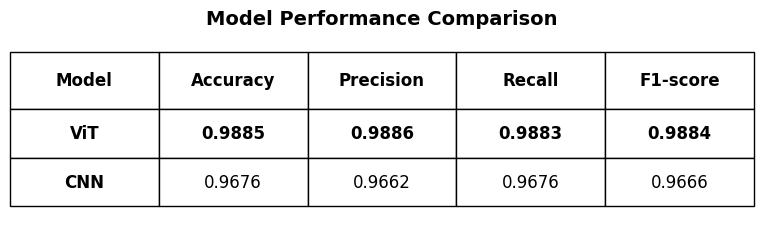

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

# ViT metrics
loaded_vit_precision = precision_score(loaded_vit_labels, loaded_vit_preds, average='macro')
loaded_vit_recall = recall_score(loaded_vit_labels, loaded_vit_preds, average='macro')
loaded_vit_f1 = f1_score(loaded_vit_labels, loaded_vit_preds, average='macro')

# CNN metrics
loaded_cnn_precision = precision_score(loaded_cnn_labels, loaded_cnn_preds, average='macro')
loaded_cnn_recall = recall_score(loaded_cnn_labels, loaded_cnn_preds, average='macro')
loaded_cnn_f1 = f1_score(loaded_cnn_labels, loaded_cnn_preds, average='macro')

print("\n------ ViT ------")
print(f"Accuracy : {loaded_vit_test_accuracy:.4f}")
print(f"Precision: {loaded_vit_precision:.4f}")
print(f"Recall   : {loaded_vit_recall:.4f}")
print(f"F1-score : {loaded_vit_f1:.4f}")

print("\n------ CNN ------")
print(f"Accuracy : {loaded_cnn_test_accuracy:.4f}")
print(f"Precision: {loaded_cnn_precision:.4f}")
print(f"Recall   : {loaded_cnn_recall:.4f}")
print(f"F1-score : {loaded_cnn_f1:.4f}")

# Plot table

import matplotlib.pyplot as plt

columns = ["Model", "Accuracy", "Precision", "Recall", "F1-score"]
data = [
    ["ViT",
     f"{loaded_vit_test_accuracy:.4f}",
     f"{loaded_vit_precision:.4f}",
     f"{loaded_vit_recall:.4f}",
     f"{loaded_vit_f1:.4f}"],
    
    ["CNN",
     f"{loaded_cnn_test_accuracy:.4f}",
     f"{loaded_cnn_precision:.4f}",
     f"{loaded_cnn_recall:.4f}",
     f"{loaded_cnn_f1:.4f}"]
]

fig, ax = plt.subplots(figsize=(8, 2.5))
ax.axis('off')

table = ax.table(
    cellText=data,
    colLabels=columns,
    loc='center',
    cellLoc='center'
)

# Styling
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 1.6)

for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_text_props(weight='bold')
        cell.set_height(0.3)
    else:
        cell.set_height(0.25)

table[(1, 0)].set_text_props(weight='bold')
table[(2, 0)].set_text_props(weight='bold')

plt.title("Model Performance Comparison", fontsize=14, weight='bold')

plt.show()

### Model interpretability

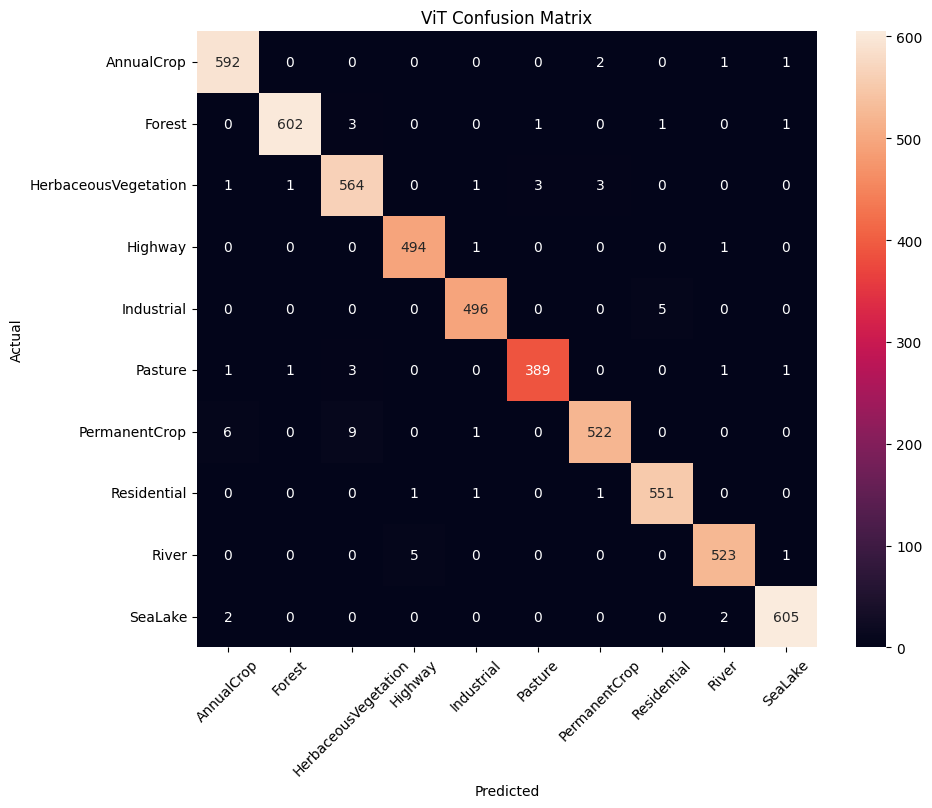

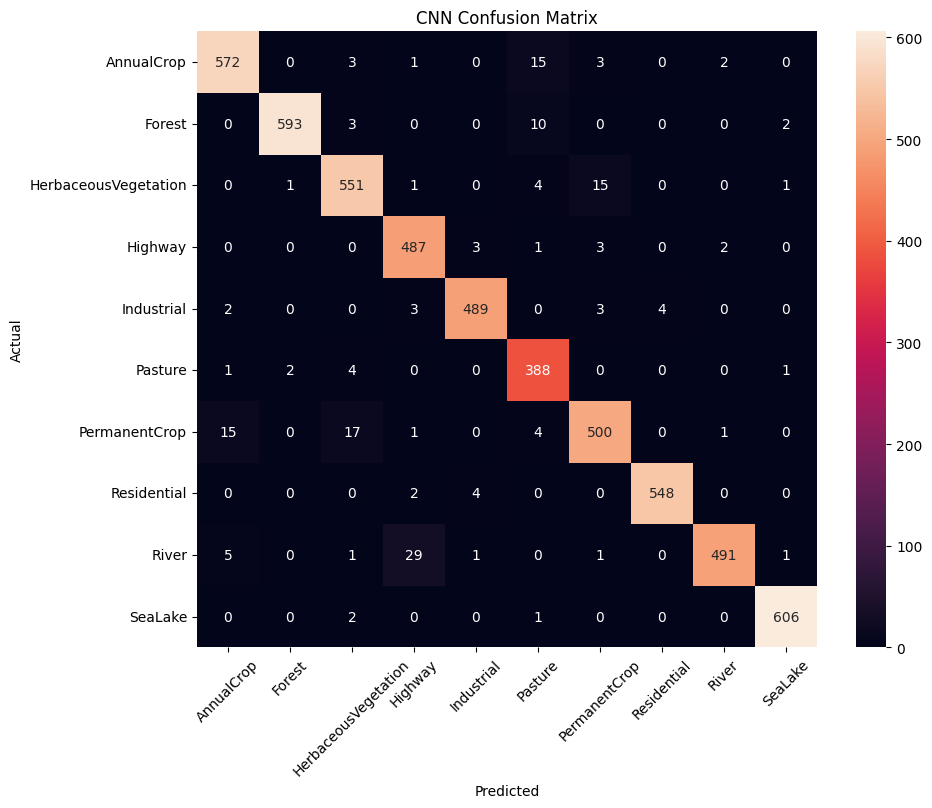

In [42]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
labels = dataset['train'].features['label'].names
cnn_labels = np.array(loaded_cnn_labels).astype(int)
cnn_preds = np.array(loaded_cnn_preds).astype(int)

vit_labels = np.array(loaded_vit_labels).astype(int)
vit_preds = np.array(loaded_vit_preds).astype(int)

# ViT Confusion Matrix

cm_vit = confusion_matrix(vit_labels, vit_preds)

plt.figure(figsize=(10,8))
sns.heatmap(
    cm_vit,
    annot=True,
    fmt='d',
    xticklabels=labels,
    yticklabels=labels
)
plt.title("ViT Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

# CNN Confusion Matrix

cm_cnn = confusion_matrix(cnn_labels, cnn_preds)

plt.figure(figsize=(10,8))
sns.heatmap(
    cm_cnn,
    annot=True,
    fmt='d',
    xticklabels=labels,
    yticklabels=labels
)
plt.title("CNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

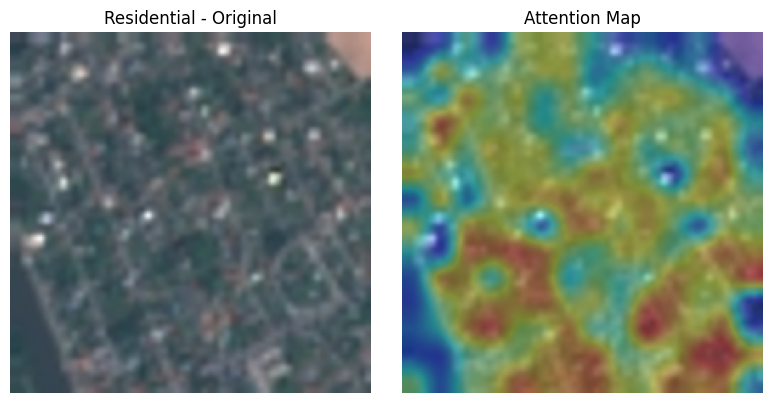

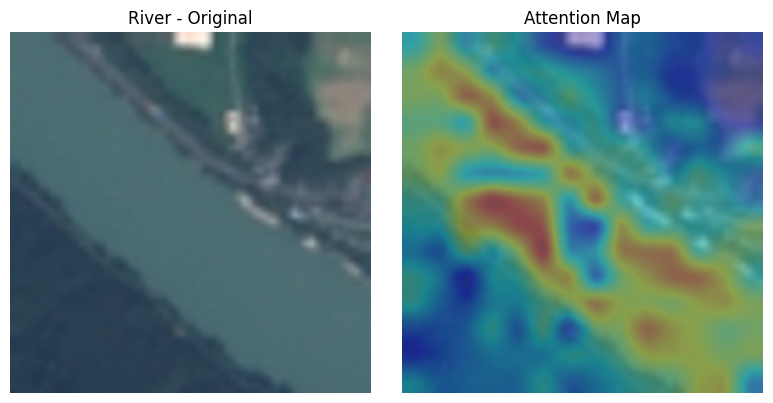

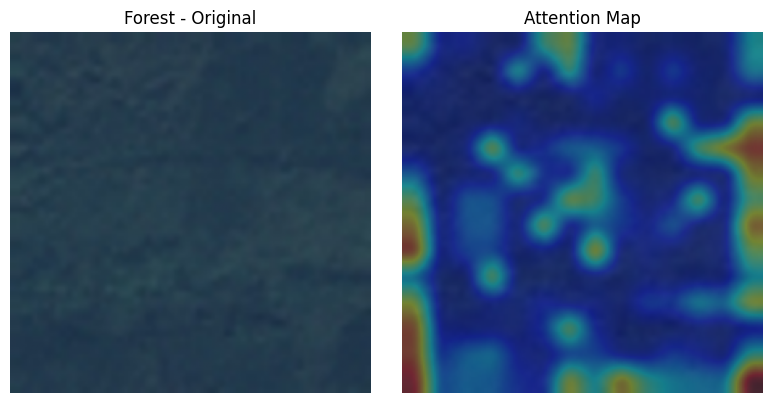

In [44]:
# ViT attention maps

import cv2
processor = ViTImageProcessor.from_pretrained("./vit-best-model")
vit_model = ViTForImageClassification.from_pretrained(
    "./vit-best-model",
    attn_implementation="eager"
)

vit_model.to(device)
vit_model.eval()

selected_labels = ["Residential", "River", "Forest"]

label_to_id = {name: i for i, name in enumerate(labels)}

for label_name in selected_labels:
    
    label_id = label_to_id[label_name]
    
    # pick one good sample
    for example in dataset['test']:
        if example['label'] == label_id:
            image_pil = example['image']
            break

    inputs = processor(images=image_pil, return_tensors="pt").to(device)

    with torch.no_grad():
        outputs = vit_model(**inputs, output_attentions=True)

    attn = outputs.attentions[-1][0]
    attn_mean = attn.mean(dim=0)
    cls_attn = attn_mean[0, 1:]

    num_patches = int(cls_attn.shape[0] ** 0.5)
    attn_map = cls_attn.reshape(num_patches, num_patches).cpu().numpy()

    attn_map = (attn_map - attn_map.min()) / (attn_map.max() - attn_map.min())

    img = np.array(image_pil.resize((224, 224))) / 255.0

    attn_resized = cv2.resize(attn_map, (224, 224))
    attn_resized = cv2.GaussianBlur(attn_resized, (15, 15), 0)

    heatmap = cv2.applyColorMap(np.uint8(255 * attn_resized), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0

    alpha = 0.35
    overlay = img * (1 - alpha) + heatmap * alpha
    overlay = np.clip(overlay, 0, 1)

    plt.figure(figsize=(8,4))

    plt.subplot(1,2,1)
    plt.imshow(img)
    plt.title(f"{label_name.capitalize()} - Original")
    plt.axis('off')

    plt.subplot(1,2,2)
    plt.imshow(overlay)
    plt.title("Attention Map")
    plt.axis('off')

    plt.tight_layout()
    plt.show()